# Pricing a European Call Option under the Black-Scholes Model

The objective of this notebook is to compute the price of a European call option at t = 0 with four different pricing methods. 

The payoff of a European call option at maturity $T$ is given by:
$$C(T,S) = \max(S_T - K, 0) = (S_T - K)^+$$

Under the Black-Scholes framework, the underlying stock price $S_t$ follows Geometric Brownian Motion (GBM):
$$dS_t = rS_t dt + \sigma S_t dW_t$$

Our goal is to compute the fair price of the option today, $C(0, S_0)$, which is the discounted expected payoff under the **risk-neutral measure**:
$$C(0, S_0) = \mathbb{E}[e^{-rT}(S_T - K)^+]$$

We will evaluate this using:
1. Closed-form Black-Scholes formula (Benchmark)
2. Cox-Ross-Rubinstein (CRR) Binomial Tree
3. Finite Difference Method (PDE)
4. Monte Carlo Simulation

In [2]:
# Import necessary libraries
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import pandas as pd
import time

## Global Parameters
We define the baseline parameters for numerical experiments.

In [3]:
# Baseline Parameters
S0 = 5.0      # Initial stock price
K = 5.0       # Strike price
r = 0.05      # Risk-free interest rate
sigma = 0.3   # Volatility
T = 1.0       # Time to maturity (in years)

### Method 1: Closed-Form Black-Scholes Formula (Benchmark)

### Method 2: CRR Binomial Model

The Cox-Ross-Rubinstein (CRR) binomial model is a discrete-time approximation to the Black-Scholes framework.

The time interval $[ 0, T ]$ is divided into $n$ periods of length

$$
\Delta t = \frac{T}{n}.
$$

At each step, the stock price either moves upward by a factor $u$ or downward by a factor $d$:

$$
u = e^{\sigma\sqrt{\Delta t}},
\qquad
d = e^{-\sigma\sqrt{\Delta t}}.
$$

Under the risk-neutral measure, the probability of an upward move is

$$
q = \frac{e^{r\Delta t} - d}{u-d}.
$$

The option value is computed by backward induction from the terminal payoff

$$
C(T,S_T)=\max(S_T-K,0).
$$

At each node of the tree, the option price satisfies

$$
C_j^i =
e^{-r\Delta t}
\left(
qC_{j+1}^{i+1}
+
(1-q)C_j^{i+1}
\right).
$$


#### 2.1 CRR Pricing Function

In [4]:
# Import necessary libraries
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import pandas as pd
import time

# Baseline Parameters
S0 = 5.0      # Initial stock price
K = 5.0       # Strike price
r = 0.05      # Risk-free interest rate
sigma = 0.3   # Volatility
T = 1.0       # Time to maturity (in years)

def option_price_crr(S0, K, r, sigma, T, n):
    """
    Computes the European call option price
    using the CRR binomial model.
    """

    # Length of each time step
    dt = T / n

    # CRR up/down factors
    u = np.exp(sigma * np.sqrt(dt))
    d = np.exp(-sigma * np.sqrt(dt))

    # Risk-neutral probability
    q = (np.exp(r * dt) - d) / (u - d)

    # Terminal stock prices
    ST = np.array([
        S0 * (u**j) * (d**(n-j))
        for j in range(n+1)
    ])

    # Terminal option payoff
    C = np.maximum(ST - K, 0)

    # Backward induction
    for i in range(n-1, -1, -1):

        C = np.exp(-r * dt) * (
            q * C[1:i+2]
            +
            (1-q) * C[0:i+1]
        )

    return C[0]

#### 2.2 Visualising the Binomial Tree

The CRR model evolves on a recombining binomial tree.

At each time step, the stock price can either move upward or downward, generating a discrete approximation to Geometric Brownian Motion.

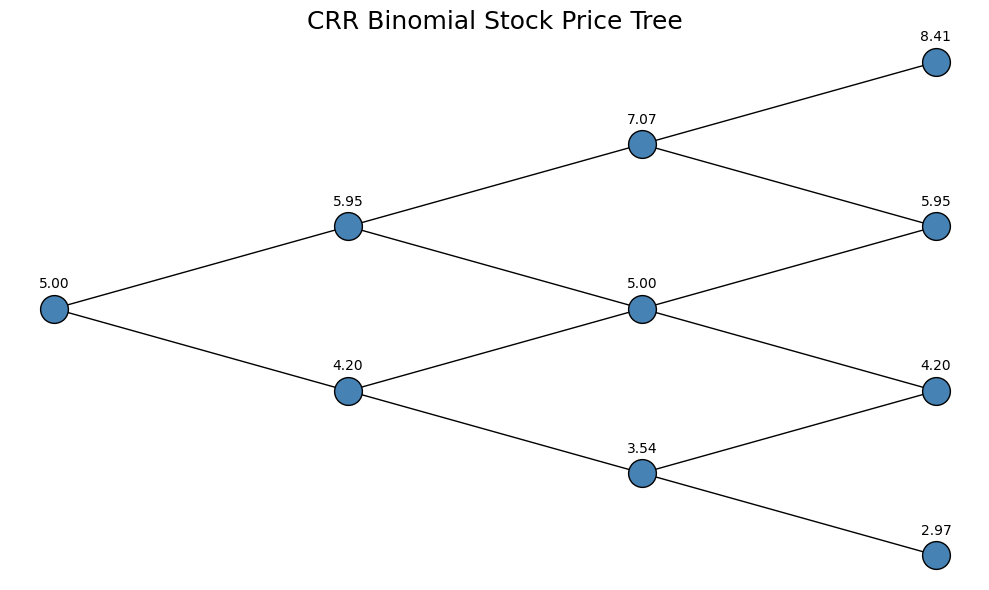

In [5]:
n_tree = 3

dt = T / n_tree

u = np.exp(sigma * np.sqrt(dt))
d = np.exp(-sigma * np.sqrt(dt))

# Generate stock price tree
tree = []

for i in range(n_tree + 1):

    level = []

    for j in range(i + 1):

        price = S0 * (u**j) * (d**(i-j))

        level.append(price)

    tree.append(level)

fig, ax = plt.subplots(figsize=(10,6))

# Plot nodes and edges
for i in range(len(tree)):

    y_positions = np.linspace(-i, i, len(tree[i]))

    for j, price in enumerate(tree[i]):

        x = i
        y = y_positions[j]

        # Draw node
        ax.scatter(
            x,
            y,
            s=400,
            color='steelblue',
            edgecolors='black',
            zorder=3
        )

        # Price label
        ax.text(
            x,
            y + 0.25,
            f"{price:.2f}",
            ha='center',
            fontsize=10
        )

        # Draw branches
        if i < n_tree:

            next_y = np.linspace(-(i+1), i+1, len(tree[i+1]))

            # Up branch
            ax.plot(
                [x, x+1],
                [y, next_y[j+1]],
                color='black',
                linewidth=1
            )

            # Down branch
            ax.plot(
                [x, x+1],
                [y, next_y[j]],
                color='black',
                linewidth=1
            )

# Formatting
ax.set_title(
    "CRR Binomial Stock Price Tree",
    fontsize=18
)

ax.axis('off')

plt.tight_layout()

plt.show()

#### 2.3 Option Price as a Function of $S_0$

We now investigate how the European call option price varies with the initial stock price $S_0$.

Keeping all other parameters fixed, we compute the CRR option price for a range of initial stock prices using the binomial pricing function developed above.

As expected, the option price increases as the underlying asset price increases.

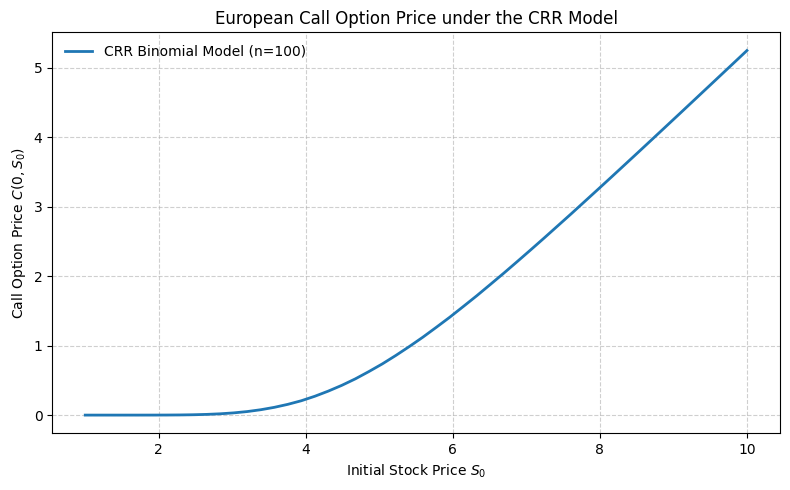

In [6]:
# Range of initial stock prices
S0_values = np.linspace(1, 10, 50)

# Store option prices
crr_prices = []

# Number of CRR periods
n_large = 100

# Compute CRR prices
for S0_current in S0_values:
    
    price = option_price_crr(
        S0_current,
        K,
        r,
        sigma,
        T,
        n_large
    )
    
    crr_prices.append(price)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    S0_values,
    crr_prices,
    linewidth=2,
    label=f'CRR Binomial Model (n={n_large})'
)

plt.xlabel(r'Initial Stock Price $S_0$')
plt.ylabel(r'Call Option Price $C(0,S_0)$')

plt.title('European Call Option Price under the CRR Model')

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Method 3: Finite Difference Method

### Method 4: Monte Carlo Simulation

By simulating $M$ independent paths of the terminal stock price under the risk-neutral assumption using the Geometric Brownian Motion equation:
$$S_T^{(m)} = S_0 \exp\left( \left(r - \frac{1}{2}\sigma^2\right)T + \sigma W_{T-0}^{(m)} \right), \quad W_{T-0}^{(m)} \sim \mathcal{N}(0,T)$$

The approximated option price $\hat{C}(0, S_0)$ could be estimate with continuous discounted average of the simulated payoffs:
$$\hat{C}(0, S_0) = e^{-rT} \frac{1}{M} \sum_{m=1}^{M} (S_T^{(m)} - K)^+$$
where $e^{-rT}$ is the continuous discount factor. 

In [ ]:
def option_price_monte_carlo(S0, K, r, sigma, T, M, seed=None):
    """
    Computes the European Call price using M rounds Monte Carlo simulations.
    Returns the estimated price and the standard error.
    """
    # Set a random seed for reproducibility 
    if seed is not None:
        np.random.seed(seed)
    
    Z = np.random.standard_normal(M)
    
    # Calculate all terminal stock prices, notice N(0, T) = sqrt(T) * N(0, 1)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Calculate payoffs for all paths then calcualte the discounted average payoff to obtain the option's value
    payoffs = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    
    # Calculate the Standard Error (to measure our uncertainty)
    standard_error = np.exp(-r * T) * np.std(payoffs) / np.sqrt(M)
    
    return price, standard_error

#### 4.1 Statistical Convergence and Confidence Intervals

Because the Monte Carlo method relies on random sampling, our calculated price $\hat{C}$ is a statistical estimator. To measure the precision of the estimate, we must calculate the standard error (SE) of the discounted payoffs. 

By the Central Limit Theorem, as the number of simulations $M$ becomes large, the distribution of our estimator approaches a normal distribution. Therefore, we can construct a 95% Confidence Interval (C.I.) for the true option price:

$$\frac{\hat{C} - C}{\hat{\sigma}} \sim \mathcal{N}(0,1) \implies 95\% \text{ C.I.} = \left[ \hat{C} - 1.96 \times SE, \ \hat{C} + 1.96 \times SE \right]
$$
Where $C$ is the true value of the option at t = 0, $\hat{\sigma}$ is the sample standard deviation.

Furthermore, the standard error is proportional to $\frac{1}{\sqrt{M}}$. This defines the $\mathcal{O}(M^{-1/2})$ convergence rate of the Monte Carlo method: to halve the estimation error, we must quadruple the number of simulated paths.

#### 4.2 Visualizing the Simulated Stock Paths, Stepping vs. Jumping

While pricing a European option only requires us to simulate the final terminal stock price $S_T$, it is instructive to visualise the continuous paths the asset takes to get there. 

To plot the trajectories, we discretise the time to maturity $T$ into $N$ steps of length $\Delta t = T/N$. The stock price evolves step-by-step according to the exact discrete solution to Geometric Brownian Motion:
$$S_{t+\Delta t} = S_t \exp\left( \left(r - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$

Below, we simulate and plot a subset of these paths. The horizontal line represents the predeterminated strike price $K$. Paths terminating above this line yield a positive payoff, while those below expire worthless.

**AI Usage**: Plot improvement. 

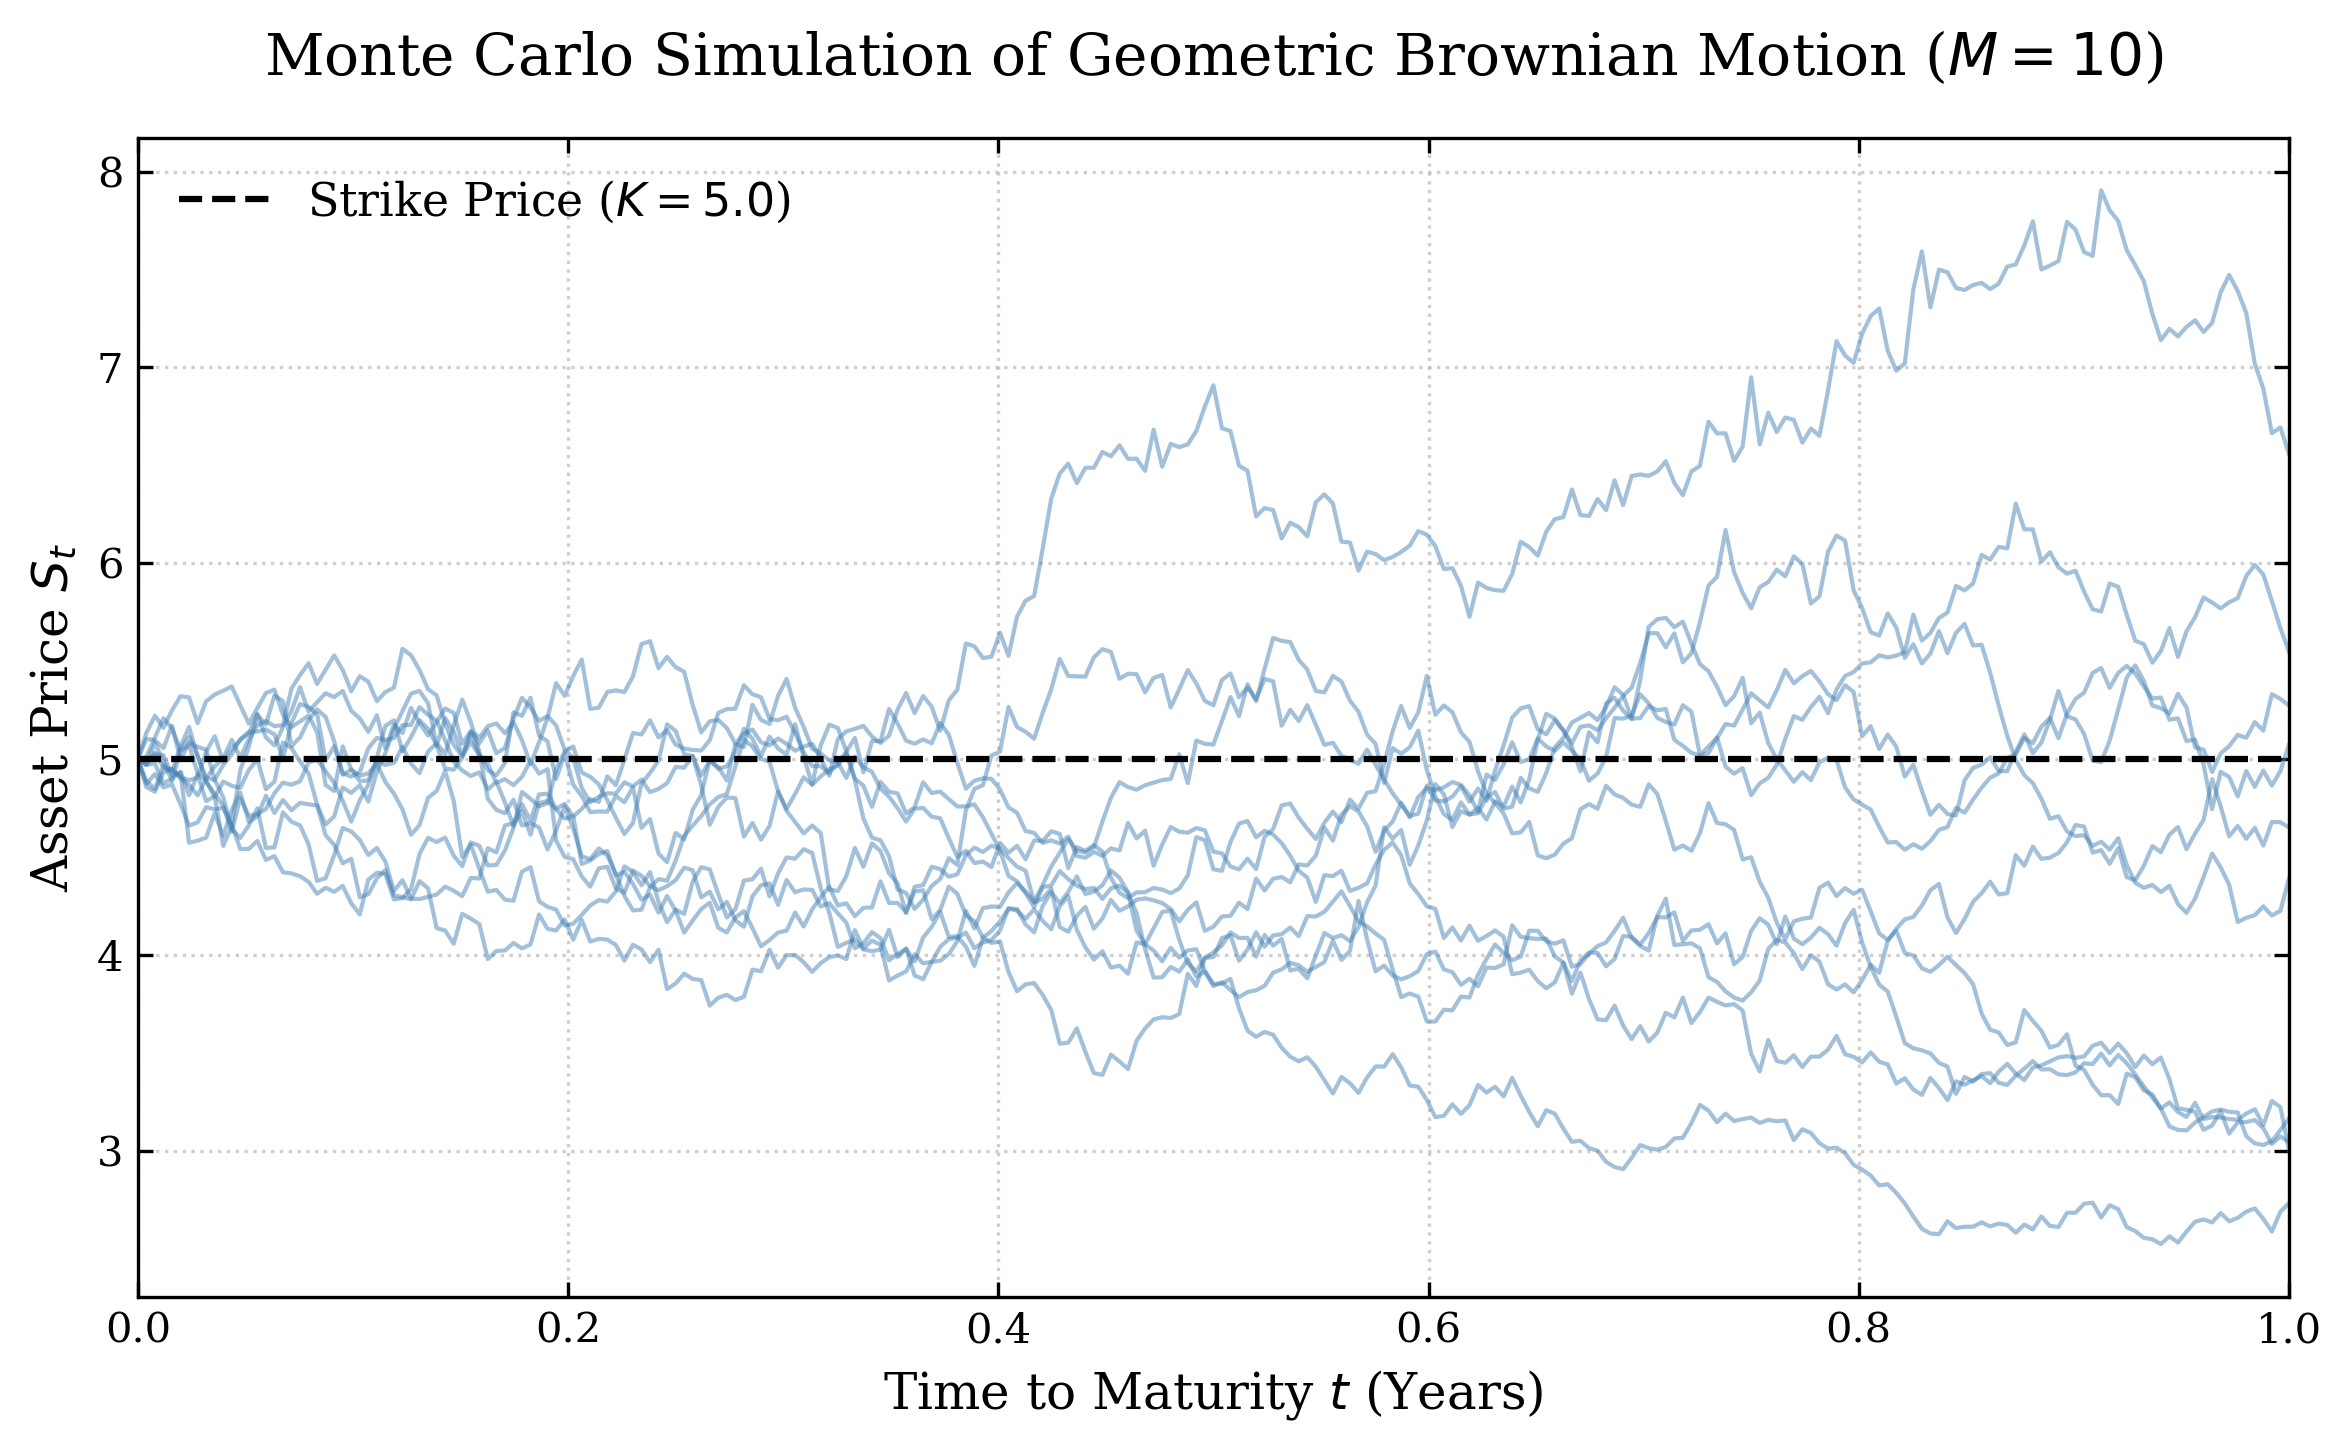

In [8]:
N = 252 # Number of trading days in a year 
M_plot = 10 # Number of paths to plot
dt = T / N

Z = np.random.standard_normal((N, M_plot))

# We use the exact discrete GBM formula
growth_factors = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

S_paths = np.zeros((N + 1, M_plot))
S_paths[0] = S0 # Set the starting price for all paths

# Loop through time to build the paths cumulatively
for t in range(1, N + 1):
    S_paths[t] = S_paths[t-1] * growth_factors[t-1]

# Create the Time array for the x-axis
time_array = np.linspace(0, T, N + 1)

import matplotlib.pyplot as plt

# 1. Configure Matplotlib for "Academic Paper" Style
plt.rcParams.update({
    "font.family": "serif",          # Use serif fonts to match LaTeX
    "axes.labelsize": 12,            # Larger axis labels
    "font.size": 12,                 # Larger general font
    "legend.fontsize": 11,           # Clean legend text
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    "figure.dpi": 300,               # High resolution for sharp PDFs
    "savefig.dpi": 300,
})

# 2. Create the figure (slightly more compact ratio looks better in reports)
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot all paths in a single, professional color (steelblue or darkgray)
# Using a single color stops the "rainbow spaghetti" effect.
# Automatically scales transparency: thicker/darker for few paths, fainter for many paths
dynamic_alpha = max(0.05, 5.0 / M_plot) 

ax.plot(time_array, S_paths, color='steelblue', linewidth=1.0, alpha=dynamic_alpha)

# 4. Add the Strike Price line (make it stark and obvious)
ax.axhline(y=K, color='black', linestyle='--', linewidth=1.5, label=f'Strike Price ($K={K}$)')

# Optional: Add the theoretical expected path (Forward Price) to show the mean
# expected_path = S0 * np.exp(r * time_array)
# ax.plot(time_array, expected_path, color='darkred', linewidth=2, label=r'Expected Path $\mathbb{E}[S_t]$')

# 5. Professional Formatting
ax.set_title(f'Monte Carlo Simulation of Geometric Brownian Motion ($M={M_plot}$)', pad=15)
ax.set_xlabel('Time to Maturity $t$ (Years)')
ax.set_ylabel('Asset Price $S_t$')
ax.set_xlim(0, T)

# Academic grid and tick marks
ax.grid(True, linestyle=':', alpha=0.6)
ax.tick_params(direction='in', which='both', top=True, right=True) # Inward ticks are standard in physics/quant journals

# 6. Clean Legend (No heavy box around it)
# We handle the legend carefully so it doesn't try to label all 100 paths
handles, labels = ax.get_legend_handles_labels()
# Only keep the strike price (and expected path) in the legend to keep it clean
ax.legend(handles, labels, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

## Numerical Experiments & Results

### 1.1 Benchmark Comparison Table
Comparing the absolute error, relative error, and runtime for each numerical method against the exact closed-form solution.

### 1.2 Sensitivity to Initial Stock Price ($S_0$)
Plotting the call option price as a function of the initial stock price $S_0 \in [2, 8]$ while holding $K, r, \sigma, T$ constant.

### 1.3 Convergence Analysis
Analyzing how the numerical errors decay as we increase computational effort (e.g., increasing tree steps $n$ or simulation paths $M$).

## Discussion & Conclusion